# Custom objective features, feasible decisions, and dataset
Only three user functions are needed for a finite linear-in-parameter model: a feature map, a feasible-decision generator, and the data records.

In [1]:
%matplotlib inline
import numpy as np
import invoptlab as io


In [2]:
def feasible_decisions(context):
    return list(range(len(context['choices'])))

def phi(context, decision):
    return np.asarray(context['choices'][int(decision)], dtype=float)

problem = io.finite_choice_problem(
    parameter_dimension=2,
    feature_map=phi,
    feasible_decisions=feasible_decisions,
    parameter_space=io.ParameterSpace(2, 'l2_ball'),
    name='my-problem',
)


Create observations manually. A context can be any Python object understood by your functions.

In [3]:
rng = np.random.default_rng(15)
theta_true = np.array([0.35, -0.94])
contexts = [{'choices': rng.normal(size=(5, 2))} for _ in range(14)]
records = []
for time, context in enumerate(contexts):
    decision = problem.solve(theta_true, context).decision
    records.append({
        'context': context, 'decision': decision,
        'clean_decision': decision, 'true_theta': theta_true, 'timestamp': time
    })
dataset = io.InverseDataset.from_records(records, name='my-data')
problem.validate_dataset(dataset)


[]

{'name': 'custom-model', 'theta': [0.32831190393483556, -0.9445693694666811], 'metrics': {'observed_decision_accuracy': 1.0, 'mean_observed_decision_distance': 0.0, 'mean_surrogate_suboptimality': 0.0, 'max_surrogate_suboptimality': 0.0, 'clean_decision_accuracy': 1.0, 'mean_clean_decision_distance': 0.0, 'mean_true_regret': 0.0, 'cumulative_true_regret': 0.0, 'max_true_regret': 0.0, 'true_regret_cvar_20': 0.0, 'parameter_angular_error': 0.02192109287580395, 'parameter_cosine_similarity': 0.9997597424647955, 'parameter_l1_error_normalized': 0.02804877444681464, 'parameter_l2_error_normalized': 0.021920653968554547, 'parameter_linf_error_normalized': 0.020625455183403085, 'parameter_sign_accuracy': 1.0, 'constraint_count': 56.0, 'constraint_violation_rate': 0.0, 'mean_constraint_violation': 0.0, 'max_constraint_violation': 0.0, 'minimum_margin': 0.03467012884315422, 'median_margin': 0.7383667119323204, 'mean_margin': 0.6568618010166186, 'fit_time_seconds': 1.147938800000702}, 'dataset':

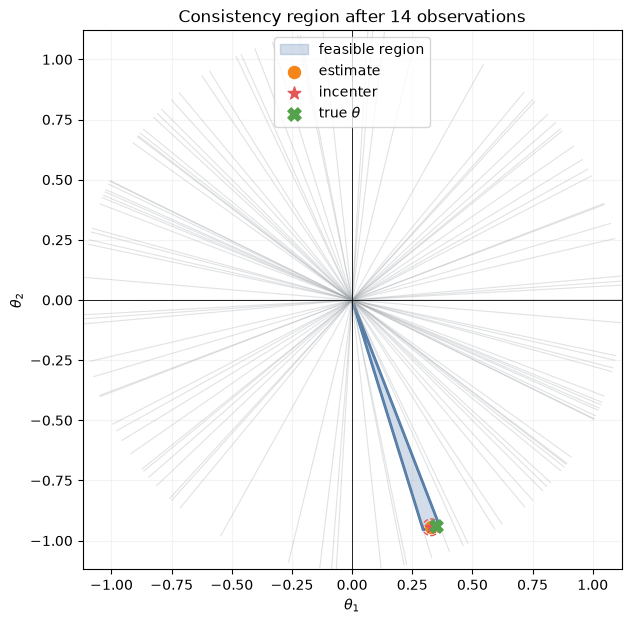

In [4]:
result = io.ExperimentRunner(io.ExperimentConfig(name='custom-model')).run(
    problem, dataset, io.IncenterEstimator(sequential_history=True)
)
print(result.summary())
result.plot_cone(problem, true_theta=theta_true);
